# Pipeline Final — Copa FutBotMX
## Visión por Computadora: Segmentación, Tracking y Análisis Táctico

**Equipo:** *Los más 3D*  
**Categoría:** Amateur  
**Video procesado:** Vista cenital con cámara fija

Este notebook integra el pipeline completo:
1. **YucaBot** (YOLOv8m fine-tuned) para detección de robots y balón
2. **SAM 3** para segmentación con máscaras precisas
3. **ByteTrack** para tracking continuo entre frames
4. **Mapa táctico** con proyección geométrica y vista cenital
5. **Visualizaciones** de heatmap y trayectorias


In [2]:
import warnings
warnings.filterwarnings("ignore")

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import supervision as sv
import torch
from pathlib import Path
from ultralytics import YOLO, SAM
from ultralytics.models.sam import SAM3SemanticPredictor

Path("assets").mkdir(exist_ok=True)

print(f"Supervision: {sv.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Supervision: 0.28.0
PyTorch: 2.11.0+cu128
CUDA disponible: True
GPU: NVIDIA GeForce RTX 5050


## 1. Configuración global

In [3]:
# ── Rutas ─────────────────────────────────────────────────────────────────
VIDEO_PATH     = "../VideosEjemplo/cenital.mov"
OUTPUT_PIPELINE = "assets/pipeline_final.mp4"
OUTPUT_HEATMAP  = "assets/heatmap_final.png"
OUTPUT_TRAILS   = "assets/trails_final.png"

# ── Campo canónico (vista cenital) ─────────────────────────────────────────
# Dimensiones en píxeles del mapa táctico (basadas en cancha real FutBotMX)
CAMPO_W, CAMPO_H = 364, 486
ESCALA_PX_CM = 2.0  # 1 cm real = 2 px en el campo canónico

TARGET_POINTS = np.float32([
    [0,       0      ],  # TL
    [CAMPO_W, 0      ],  # TR
    [CAMPO_W, CAMPO_H],  # BR
    [0,       CAMPO_H],  # BL
])

# ── Puntos SOURCE en el video cenital.mov (vista cenital fija) ───────────────
# Estos puntos corresponden a las 4 esquinas de la cancha en el video
# Ajusta si usas un video distinto
SOURCE_POINTS = np.float32([
    [ 260,  200],   # esquina superior-izquierda
    [1070,   220],   # esquina superior-derecha
    [1050, 1730],   # esquina inferior-derecha
    [ 120,  1470],   # esquina inferior-izquierda
])

# ── Colores por clase (BGR) ────────────────────────────────────────────────
# class 0 = ball, class 1 = robot
COLORS_BGR = {
    0: (0,   200, 255),   # balón  → naranja
    1: (239,  35,  60),   # robot  → rojo/azul alternado por tracker_id
}

# Calcular matriz de homografía
H_matrix = cv2.getPerspectiveTransform(SOURCE_POINTS, TARGET_POINTS)
print("✓ Configuración lista")
print(f"  Campo canónico: {CAMPO_W}×{CAMPO_H} px")
print(f"  Matriz H calculada")


✓ Configuración lista
  Campo canónico: 364×486 px
  Matriz H calculada


## 2. Verificar puntos SOURCE sobre el video

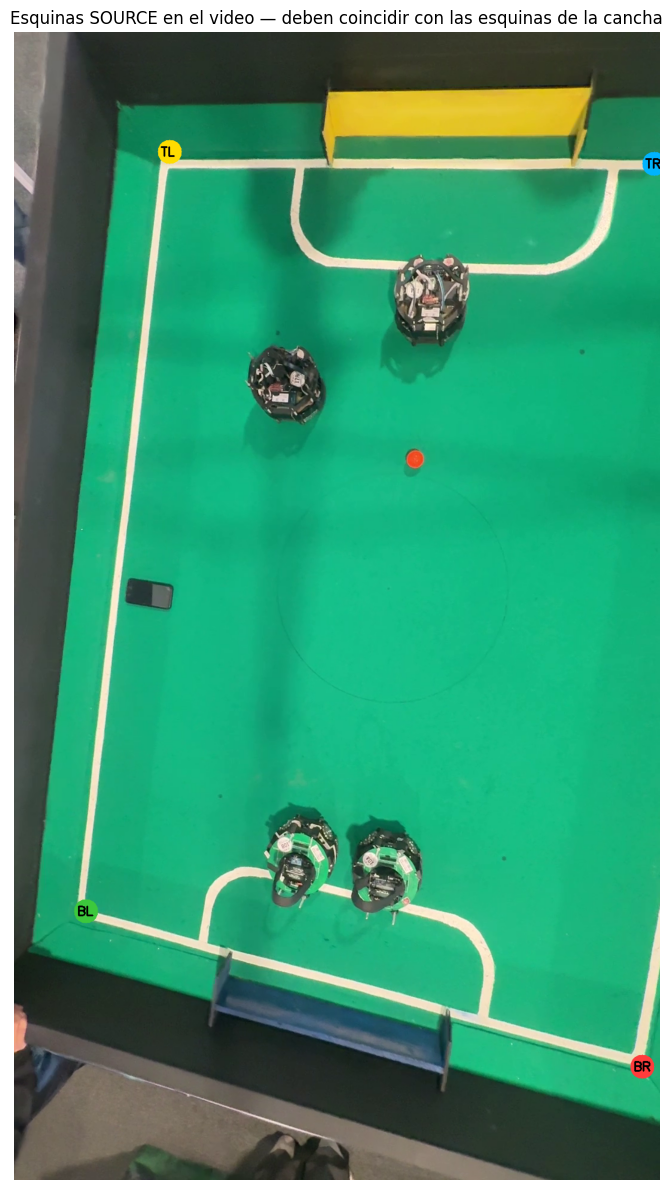

Si los puntos no coinciden con las esquinas, ajusta SOURCE_POINTS en la celda anterior


In [4]:
# Verificar que los puntos SOURCE están bien colocados
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
ret, frame_check = cap.read()
cap.release()

vis = cv2.cvtColor(frame_check, cv2.COLOR_BGR2RGB).copy()
colores_vis = [(255, 220, 0), (0, 180, 255), (255, 60, 60), (60, 200, 60)]
nombres = ["TL", "TR", "BR", "BL"]

for idx, (pt, color, nombre) in enumerate(zip(SOURCE_POINTS, colores_vis, nombres)):
    x, y = int(pt[0]), int(pt[1])
    cv2.circle(vis, (x, y), 20, color, -1)
    cv2.putText(vis, nombre, (x-15, y+7), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,0), 2)

plt.figure(figsize=(8, 12))
plt.imshow(vis)
plt.title("Esquinas SOURCE en el video — deben coincidir con las esquinas de la cancha")
plt.axis("off")
plt.tight_layout()
plt.savefig("assets/verificacion_source_points.png", dpi=100, bbox_inches="tight")
plt.show()
print("Si los puntos no coinciden con las esquinas, ajusta SOURCE_POINTS en la celda anterior")


## 3. Cargar modelos

In [5]:
# ── YucaBot (detector especializado) ──────────────────────────────────────
yolo_model = YOLO("../yucabot.pt")
print(f"✓ YucaBot cargado — clases: {yolo_model.names}")

# ── SAM 3 (segmentador) ────────────────────────────────────────────────────
sam_model = SAM("sam3.pt")
print("✓ SAM 3 cargado")

# ── Anotadores ────────────────────────────────────────────────────────────
mask_annotator  = sv.MaskAnnotator(opacity=0.45)
box_annotator   = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_scale=0.5)
trace_annotator = sv.TraceAnnotator(thickness=2, trace_length=40)

# ── Tracker ───────────────────────────────────────────────────────────────
tracker = sv.ByteTrack()
tracker.reset()

# ── Memoria para interpolación ────────────────────────────────────────────
ultima_det_valida = None
frames_sin_det    = 0
MAX_FRAMES_SIN_DET = 15

print("Todo listo para procesar")


✓ YucaBot cargado — clases: {0: 'ball', 1: 'robot'}
✓ SAM 3 cargado
Todo listo para procesar


## 4. Funciones auxiliares

In [6]:
def project_point(x: float, y: float, H: np.ndarray):
    """Proyecta un punto del video al campo canónico usando la homografía H."""
    pt  = np.float32([[[x, y]]])
    proj = cv2.perspectiveTransform(pt, H)
    return int(proj[0][0][0]), int(proj[0][0][1])


def project_detections(detections: sv.Detections, H: np.ndarray) -> list:
    """Proyecta todas las detecciones al campo canónico."""
    puntos = []
    if len(detections) == 0 or detections.tracker_id is None:
        return puntos

    for box, cid, tid in zip(detections.xyxy, detections.class_id, detections.tracker_id):
        cx = (box[0] + box[2]) / 2
        # Robots: usar base inferior (más preciso con perspectiva)
        # Balón: usar centroide
        cy = box[3] if int(cid) == 1 else (box[1] + box[3]) / 2

        px, py = project_point(cx, cy, H)
        puntos.append({
            "pos"       : (px, py),
            "class_id"  : int(cid),
            "tracker_id": int(tid),
        })
    return puntos


def draw_tactical_canvas(puntos: list, heatmap_acc: np.ndarray = None) -> np.ndarray:
    """Dibuja el mapa táctico con los objetos proyectados."""
    canvas = np.zeros((CAMPO_H, CAMPO_W, 3), dtype=np.uint8)
    canvas[:] = (50, 67, 27)  # verde pasto

    # Líneas de la cancha
    cv2.rectangle(canvas, (0, 0), (CAMPO_W-1, CAMPO_H-1), (120, 200, 116), 2)
    cv2.line(canvas, (0, CAMPO_H//2), (CAMPO_W, CAMPO_H//2), (120, 200, 116), 1)
    cv2.circle(canvas, (CAMPO_W//2, CAMPO_H//2), int(30*ESCALA_PX_CM), (120, 200, 116), 1)

    # Porterías
    gw = int(60 * ESCALA_PX_CM)
    gx = (CAMPO_W - gw) // 2
    cv2.rectangle(canvas, (gx, 0), (gx+gw, int(8*ESCALA_PX_CM)), (0, 214, 255), 2)
    cv2.rectangle(canvas, (gx, CAMPO_H-int(8*ESCALA_PX_CM)), (gx+gw, CAMPO_H-1), (216, 180, 0), 2)

    for p in puntos:
        x, y   = p["pos"]
        cid    = p["class_id"]
        tid    = p["tracker_id"]

        if not (0 <= x < CAMPO_W and 0 <= y < CAMPO_H):
            continue

        color = COLORS_BGR.get(cid, (255, 255, 255))
        r = 6 if cid == 0 else 12
        cv2.circle(canvas, (x, y), r, color, -1)
        cv2.circle(canvas, (x, y), r, (255, 255, 255), 1)
        if cid == 1:
            cv2.putText(canvas, str(tid), (x-5, y+4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.38, (255,255,255), 1)

    return canvas


# Acumuladores para heatmap y trails
heatmap_acc   = np.zeros((CAMPO_H, CAMPO_W), dtype=np.float32)
trails_canvas = np.zeros((CAMPO_H, CAMPO_W, 3), dtype=np.uint8)
trails_canvas[:] = (50, 67, 27)
# Líneas de cancha en trails
cv2.rectangle(trails_canvas, (0, 0), (CAMPO_W-1, CAMPO_H-1), (120, 200, 116), 2)
cv2.line(trails_canvas, (0, CAMPO_H//2), (CAMPO_W, CAMPO_H//2), (120, 200, 116), 1)

print("✓ Funciones auxiliares definidas")


✓ Funciones auxiliares definidas


## 5. Pipeline principal

In [8]:
def pipeline_callback(frame: np.ndarray, frame_idx: int) -> np.ndarray:
    global ultima_det_valida, frames_sin_det, heatmap_acc, trails_canvas

    # ── Paso 1: YucaBot detecta ───────────────────────────────────────────
    yolo_results = yolo_model(frame, verbose=False)[0]
    yolo_det     = sv.Detections.from_ultralytics(yolo_results)
    yolo_det     = yolo_det[yolo_det.confidence >= 0.50]

    if len(yolo_det) > 0:
        # ── Paso 2: SAM 3 refina con las cajas de YucaBot ─────────────────
        bboxes = yolo_det.xyxy.tolist()
        try:
            sam_results = sam_model(frame, bboxes=bboxes, imgsz=1036, verbose=False)[0]
            sam_det     = sv.Detections.from_ultralytics(sam_results)
        except Exception:
            sam_det = sv.Detections.empty()

        # ── Paso 3: Tracking ───────────────────────────────────────────────
        yolo_det = tracker.update_with_detections(yolo_det)

        usar_sam = len(sam_det) == len(yolo_det) and len(sam_det) > 0
        det_final = sam_det if usar_sam else yolo_det

        det_final.tracker_id = yolo_det.tracker_id
        det_final.class_id   = yolo_det.class_id
        det_final.confidence = yolo_det.confidence

        ultima_det_valida = det_final
        frames_sin_det    = 0
    else:
        # Interpolación cuando SAM no detecta nada
        frames_sin_det += 1
        if ultima_det_valida is not None and frames_sin_det <= MAX_FRAMES_SIN_DET:
            det_final = ultima_det_valida
        else:
            # Frame sin detección y sin memoria — devolver frame limpio con mapa vacío
            resized  = cv2.resize(frame, (int(frame.shape[1] * CAMPO_H / frame.shape[0]), CAMPO_H))
            tactical = draw_tactical_canvas([])
            return np.hstack([resized, tactical])

    # ── Paso 4: Etiquetas ─────────────────────────────────────────────────
    if det_final.tracker_id is not None:
        labels = [
            f"{yolo_model.names[c]} #{t}"
            for c, t in zip(det_final.class_id, det_final.tracker_id)
        ]
    else:
        labels = []

    # ── Paso 5: Anotar frame original ─────────────────────────────────────
    usar_mascaras = hasattr(det_final, "mask") and det_final.mask is not None
    if usar_mascaras:
        annotated = mask_annotator.annotate(scene=frame.copy(), detections=det_final)
    else:
        annotated = box_annotator.annotate(scene=frame.copy(), detections=det_final)

    if labels:
        annotated = label_annotator.annotate(scene=annotated, detections=det_final, labels=labels)
    annotated = trace_annotator.annotate(scene=annotated, detections=det_final)

    # ── Paso 6: Proyección y mapa táctico ─────────────────────────────────
    puntos   = project_detections(det_final, H_matrix)
    tactical = draw_tactical_canvas(puntos)

    # ── Paso 7: Acumular heatmap y trails ─────────────────────────────────
    for p in puntos:
        x, y = p["pos"]
        if 0 <= x < CAMPO_W and 0 <= y < CAMPO_H:
            cv2.circle(heatmap_acc, (x, y), 10, 1.0, -1)
            color_trail = COLORS_BGR.get(p["class_id"], (255,255,255))
            cv2.circle(trails_canvas, (x, y), 2, color_trail, -1)

    # ── Paso 8: Componer frame final (original + mapa táctico) ─────────────
    escala  = CAMPO_H / frame.shape[0]
    orig_w  = int(frame.shape[1] * escala)
    resized = cv2.resize(annotated, (orig_w, CAMPO_H))

    return np.hstack([resized, tactical])


print("✓ Pipeline definido — listo para procesar")


✓ Pipeline definido — listo para procesar


## 6. Procesar video completo

In [10]:
# Resetear tracker y acumuladores antes de procesar
tracker.reset()
heatmap_acc[:]   = 0
trails_canvas[:] = (50, 67, 27)
cv2.rectangle(trails_canvas, (0, 0), (CAMPO_W-1, CAMPO_H-1), (120, 200, 116), 2)
cv2.line(trails_canvas, (0, CAMPO_H//2), (CAMPO_W, CAMPO_H//2), (120, 200, 116), 1)
ultima_det_valida = None
frames_sin_det    = 0

original_info = sv.VideoInfo.from_video_path(VIDEO_PATH)

escala_h = CAMPO_H / original_info.height
orig_w   = int(original_info.width * escala_h)
ancho_final = orig_w + CAMPO_W

custom_info = sv.VideoInfo(
    width  = ancho_final,
    height = CAMPO_H,
    fps    = original_info.fps
)

print(f"Video de entrada : {original_info.width}×{original_info.height} @ {original_info.fps:.1f} fps")
print(f"Video de salida  : {ancho_final}×{CAMPO_H} px")
print(f"Frames totales   : {original_info.total_frames}")
print(f"Guardando en     : {OUTPUT_PIPELINE}")
print("Procesando...")

sv.process_video(
    source_path = VIDEO_PATH,
    target_path = OUTPUT_PIPELINE,
    callback    = pipeline_callback
)

print(f"\nVideo guardado: {OUTPUT_PIPELINE}")


Video de entrada : 1080×1920 @ 30.0 fps
Video de salida  : 637×486 px
Frames totales   : 23278
Guardando en     : assets/pipeline_final.mp4
Procesando...


KeyboardInterrupt: 

## 7. Generar heatmap de actividad

In [ ]:
# Normalizar y aplicar colormap al heatmap
heatmap_norm = cv2.normalize(heatmap_acc, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
heatmap_color = cv2.applyColorMap(heatmap_norm, cv2.COLORMAP_JET)

# Superponer sobre el fondo verde de la cancha
campo_fondo = np.zeros((CAMPO_H, CAMPO_W, 3), dtype=np.uint8)
campo_fondo[:] = (50, 67, 27)
cv2.rectangle(campo_fondo, (0, 0), (CAMPO_W-1, CAMPO_H-1), (120, 200, 116), 2)
cv2.line(campo_fondo, (0, CAMPO_H//2), (CAMPO_W, CAMPO_H//2), (120, 200, 116), 1)
cv2.circle(campo_fondo, (CAMPO_W//2, CAMPO_H//2), int(30*ESCALA_PX_CM), (120, 200, 116), 1)

mask_activa = heatmap_norm > 5
heatmap_final = campo_fondo.copy()
heatmap_final[mask_activa] = cv2.addWeighted(
    campo_fondo, 0.3, heatmap_color, 0.7, 0
)[mask_activa]

# Guardar y mostrar
cv2.imwrite(OUTPUT_HEATMAP, heatmap_final)

plt.figure(figsize=(5, 7))
plt.imshow(cv2.cvtColor(heatmap_final, cv2.COLOR_BGR2RGB))
plt.title("Heatmap de actividad — campo canónico")
plt.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_HEATMAP.replace(".png", "_plt.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Heatmap guardado: {OUTPUT_HEATMAP}")


## 8. Generar mapa de trayectorias (trails)

In [ ]:
# Añadir leyenda al canvas de trails
leyenda_items = [
    ("Balón",  COLORS_BGR[0]),
    ("Robot",  COLORS_BGR[1]),
]
for i, (nombre, color) in enumerate(leyenda_items):
    y_pos = 20 + i * 20
    cv2.circle(trails_canvas, (12, y_pos), 5, color, -1)
    cv2.putText(trails_canvas, nombre, (22, y_pos+4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)

cv2.imwrite(OUTPUT_TRAILS, trails_canvas)

plt.figure(figsize=(5, 7))
plt.imshow(cv2.cvtColor(trails_canvas, cv2.COLOR_BGR2RGB))
plt.title("Trayectorias (trails) — campo canónico")
plt.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_TRAILS.replace(".png", "_plt.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Trails guardado: {OUTPUT_TRAILS}")


## 9. Resumen de archivos generados

In [ ]:
import os

archivos = [OUTPUT_PIPELINE, OUTPUT_HEATMAP, OUTPUT_TRAILS]
print("Archivos generados:")
for f in archivos:
    if os.path.exists(f):
        size_mb = os.path.getsize(f) / 1_000_000
        print(f"  ✓ {f} ({size_mb:.1f} MB)")
    else:
        print(f"  ✗ {f} — NO encontrado")

print("")
print("Próximos pasos:")
print("  1. Revisar pipeline_final.mp4 en VLC")
print("  2. Recortar los mejores 2 minutos para el video demo")
print("  3. Hacer el Reel de Instagram (≥30 segundos)")
print("  4. Agregar capturas al README.md")
